# **Target Distribution EDA**

Decide: log-transform vs raw ratio for Model B and Model C targets.

- **Model B target**: `price / ref_base_price`, ***ref_base_price*** is the base price determined by csfloat as they calim:
"The base "reference" price of this item across multiple real-money marketplaces"
- **Model C target**: `price / ref_predicted_price` ***ref_predicted_price*** is the ***ref_base_price*** affected by `Item Factor` which in turn is:<br>
##### **The impact of "float value" or wear on the skin's price. For instance, the overpay that you'd get for a 0.01 vs 0.06 float value skin. The relative popularity of this skin, and it's propensity to sell below the typical listing price on real-money marketplaces How much CSFloat buyers typically desire this skin**


Decision rule: we gonna use log if `max/median > ~5` or `|skew| > 1.5`. Results will be stored @`docs/target_choice.md`.

## **1. Load env vars**

In [1]:
%load_ext dotenv
%dotenv

## **2. Connect + Pull**

In [2]:
import os

import clickhouse_connect
import polars as pl
import pandas as pd

ch_user: str = os.environ.get("CLICKHOUSE_USER")
ch_pass: str = os.environ.get("CLICKHOUSE_PASSWORD")

sql_file_path: str = '../sql/004_csfloat_sales_eda.sql'

client = clickhouse_connect.get_client(host='localhost', port=8023, username=ch_user, password=ch_pass)

with open(sql_file_path, 'r') as f:
    query = f.read()

df: pd.DataFrame | pl.DataFrame = client.query_df(query)
df = pl.from_pandas(df) if isinstance(df, pd.DataFrame) else df
print(f"Rows: {len(df):,}")
df.head(5)


Rows: 365,127


id,sold_at,price,ref_base_price,ref_predicted_price,market_hash_name,wear_name,is_stattrak,is_souvenir,float_value,n_stickers,_snapshot_date
str,datetime[μs],i32,i32,i32,str,str,bool,bool,f32,u64,datetime[ms]
"""1000803569865198700""",2026-08-01 08:02:38.959965,1072,1018,1200,"""AK-47 | Aphrodite (Battle-Scar…","""Battle-Scarred""",false,false,0.642797,1,2026-08-01 00:00:00
"""1000823014046174749""",2026-07-29 16:14:12.044523,1032,1033,1276,"""AK-47 | Aphrodite (Battle-Scar…","""Battle-Scarred""",false,false,0.892662,1,2026-08-01 00:00:00
"""1001068384349193512""",2026-07-31 18:56:56.505121,1069,1018,1209,"""AK-47 | Aphrodite (Battle-Scar…","""Battle-Scarred""",false,false,0.67056,0,2026-08-01 00:00:00
"""1001070153749889824""",2026-08-01 08:02:38.959965,1069,1018,1147,"""AK-47 | Aphrodite (Battle-Scar…","""Battle-Scarred""",false,false,0.733643,0,2026-08-01 00:00:00
"""1001419515315225097""",2026-07-31 08:39:23.668335,1087,1018,1174,"""AK-47 | Aphrodite (Battle-Scar…","""Battle-Scarred""",false,false,0.465422,0,2026-08-01 00:00:00


## **3. Data Quality**

In [3]:
total: int = len(df)

invalid_base   = (df['ref_base_price'] <= 0).sum()
invalid_pred   = (df['ref_predicted_price'] <= 0).sum()
invalid_price  = (df['price'] <= 0).sum()

print(f"Total rows          : {total:,}")
print(f"ref_base_price <= 0 : {invalid_base:,}  ({invalid_base/total:.2%})")
print(f"ref_predicted  <= 0 : {invalid_pred:,}  ({invalid_pred/total:.2%})")
print(f"price <= 0          : {invalid_price:,}  ({invalid_price/total:.2%})")

# Drop rows where either denominator is zero
df_clean = df.filter(
    (pl.col('ref_base_price') > 0) &
    (pl.col('ref_predicted_price') > 0) &
    (pl.col('price') > 0)
)
print(f"\nSurvived instances number: {len(df_clean):,} (Survived: {len(df_clean):,})")

Total rows          : 365,127
ref_base_price <= 0 : 0  (0.00%)
ref_predicted  <= 0 : 0  (0.00%)
price <= 0          : 0  (0.00%)

Survived instances number: 365,127 (Survived: 365,127)


## **4. Compute Targets + Apex Outlier Identification**

In [4]:
thresh: float = 10.0  

df_clean = df_clean.with_columns([
    (pl.col('price') / pl.col('ref_base_price')).alias('target_b'),
    (pl.col('price') / pl.col('ref_predicted_price')).alias('target_c'),
])

apex_b = df_clean.filter(pl.col('target_b') > thresh)
apex_c = df_clean.filter(pl.col('target_c') > thresh)

print(f"Apex outliers (target_b > {thresh}): {len(apex_b):,}")
print(apex_b.select(['market_hash_name', 'wear_name', 'float_value', 'target_b', 'target_c'])
      .sort('target_b', descending=True).head(20).to_pandas().to_string(index=False))

print(f"\nApex outliers (target_c > {thresh}): {len(apex_c):,}")
print(apex_c.select(['market_hash_name', 'wear_name', 'float_value', 'target_b', 'target_c'])
      .sort('target_c', descending=True).head(20).to_pandas().to_string(index=False))

Apex outliers (target_b > 10.0): 3,868
                         market_hash_name    wear_name  float_value      target_b      target_c
    SG 553 | Waves Perforated (Well-Worn)    Well-Worn     0.383376 120893.000000 120893.000000
    SG 553 | Waves Perforated (Well-Worn)    Well-Worn     0.383376 104500.000000 104500.000000
     P90 | Desert Halftone (Minimal Wear) Minimal Wear     0.084486  90000.000000  90000.000000
        G3SG1 | Green Cell (Field-Tested) Field-Tested     0.276660  86000.000000  86000.000000
               AUG | Storm (Field-Tested) Field-Tested     0.267939  73937.000000  73937.000000
               AUG | Storm (Field-Tested) Field-Tested     0.267939  67500.000000  67500.000000
    Five-SeveN | Forest Night (Well-Worn)    Well-Worn     0.391020  43300.000000  43300.000000
      P250 | Boreal Forest (Field-Tested) Field-Tested     0.156430  38000.000000  38000.000000
     P90 | Desert Halftone (Field-Tested) Field-Tested     0.166353  35000.000000  35000.000000
 

## **5. Distribution Stats**

In [5]:
import numpy as np
from scipy import stats

def dist_stats(series: pl.Series, label: str) -> None:
    
    arr = series.drop_nulls().to_numpy()
    median = np.median(arr)
    print(f"\n--- {label} ---")
    print(f"  n          : {len(arr):,}")
    print(f"  min        : {arr.min():.4f}")
    print(f"  p25        : {np.percentile(arr, 25):.4f}")
    print(f"  median     : {median:.4f}")
    print(f"  p75        : {np.percentile(arr, 75):.4f}")
    print(f"  max        : {arr.max():.4f}")
    print(f"  max/median : {arr.max() / median:.2f}")
    print(f"  mean       : {arr.mean():.4f}")
    print(f"  std        : {arr.std():.4f}")
    print(f"  skew       : {stats.skew(arr):.4f}")
    print(f"  kurtosis   : {stats.kurtosis(arr):.4f}")

df_filtered = df_clean.filter(
    (pl.col('target_b') <= thresh) &
    (pl.col('target_c') <= thresh)
)
print(f"Rows after apex filter: {len(df_filtered):,} (removed {len(df_clean) - len(df_filtered):,} apex outliers)")

# Stats with apex outliers (full set)
print("\n=== With apex outliers ===")
dist_stats(df_clean['target_b'], 'Model B  (price / ref_base_price)')
dist_stats(df_clean['target_c'], 'Model C  (price / ref_predicted_price)')

# Stats without apex outliers (filtered set)
print("\n=== Without apex outliers (ratio <= 10) ===")
dist_stats(df_filtered['target_b'], 'Model B  (price / ref_base_price)')
dist_stats(df_filtered['target_c'], 'Model C  (price / ref_predicted_price)')

Rows after apex filter: 361,239 (removed 3,888 apex outliers)

=== With apex outliers ===

--- Model B  (price / ref_base_price) ---
  n          : 365,127
  min        : 0.0013
  p25        : 0.9494
  median     : 1.0000
  p75        : 1.1463
  max        : 120893.0000
  max/median : 120893.00
  mean       : 5.8969
  std        : 425.9011
  skew       : 191.3121
  kurtosis   : 43055.1396

--- Model C  (price / ref_predicted_price) ---
  n          : 365,127
  min        : 0.0014
  p25        : 0.9501
  median     : 1.0000
  p75        : 1.0847
  max        : 120893.0000
  max/median : 120893.00
  mean       : 5.7405
  std        : 424.8831
  skew       : 192.5659
  kurtosis   : 43465.8969

=== Without apex outliers (ratio <= 10) ===

--- Model B  (price / ref_base_price) ---
  n          : 361,239
  min        : 0.0013
  p25        : 0.9485
  median     : 1.0000
  p75        : 1.1359
  max        : 10.0000
  max/median : 10.00
  mean       : 1.2400
  std        : 0.8238
  skew       :

## **6. Plots**

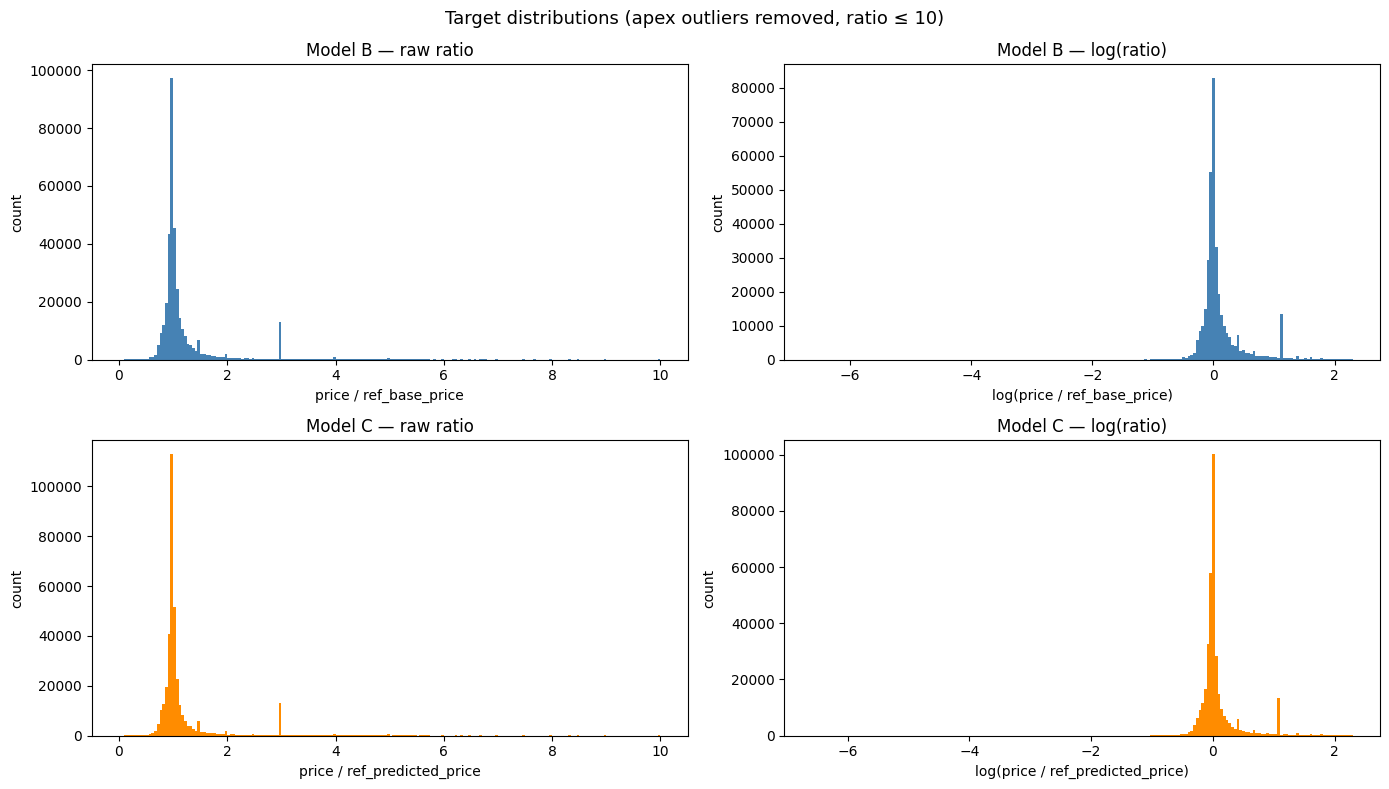

In [6]:
import matplotlib.pyplot as plt

b = df_filtered['target_b'].to_numpy()
c = df_filtered['target_c'].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Target distributions (apex outliers removed, ratio ≤ 10)', fontsize=13)

# Model B raw
axes[0, 0].hist(b, bins=200, color='steelblue', edgecolor='none')
axes[0, 0].set_title('Model B — raw ratio')
axes[0, 0].set_xlabel('price / ref_base_price')
axes[0, 0].set_ylabel('count')

# Model B log
axes[0, 1].hist(np.log(b[b > 0]), bins=200, color='steelblue', edgecolor='none')
axes[0, 1].set_title('Model B — log(ratio)')
axes[0, 1].set_xlabel('log(price / ref_base_price)')
axes[0, 1].set_ylabel('count')

# Model C raw
axes[1, 0].hist(c, bins=200, color='darkorange', edgecolor='none')
axes[1, 0].set_title('Model C — raw ratio')
axes[1, 0].set_xlabel('price / ref_predicted_price')
axes[1, 0].set_ylabel('count')

# Model C log
axes[1, 1].hist(np.log(c[c > 0]), bins=200, color='darkorange', edgecolor='none')
axes[1, 1].set_title('Model C — log(ratio)')
axes[1, 1].set_xlabel('log(price / ref_predicted_price)')
axes[1, 1].set_ylabel('count')

plt.tight_layout()
plt.savefig('target_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## **7. Decision**


**Skew** is **~191** and **~5** for *target B* and *target C* respectively. Thus in any way **log** will be an ultimate choice for modeling.

